## Resnet and H-ACN implementation

In [120]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm.notebook import tqdm
from torch.utils.data import random_split
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Random Hierarchical Model with paper parameters

In [121]:
class RHM_Dataset(Dataset):
    def __init__(self,num_samples, L = 3, s = 2, m =7, v= 14, num_classes = 2, seed = 42): #L = 4, s = 2, m =4, v= 8, num_classes = 2, seed = 42
        self.num_samples = num_samples
        self.L = L
        self.s = s
        self.m = m
        self.v = v
        self.num_classes = num_classes

        random.seed(seed)
        np.random.seed(seed)

        # construction of grammar - tree rules
        self.rules = self._generate_grammar()

        # generate data
        self.data, self.labels = self._generate_dataset()

    def _generate_grammar(self):
        rules = {}

        # for every level we create random rules
        # define intermediate for voc for intermediate levels
        intermediate_vocab = 20

        for level in range(self.L):
            rules[level] = {}
            # parents of level. for level = 0 ---> classes (0,1)
            parent_nodes = range(self.num_classes) if level == 0 else range(intermediate_vocab)

            # For every parent we make ''m '' rules
            for parent in parent_nodes:
                synonyms = []
                for _ in range(self.m):
                    if level == self.L - 1:
                        # for last level, children are from vocab v
                        child_tuple = tuple(random.choices(range(self.v), k = self.s))

                    else:
                        # in intermidiate levels, children are from  intermediate vocab
                        child_tuple = tuple(random.choices(range(intermediate_vocab), k = self.s))

                    synonyms.append(child_tuple)

                rules[level][parent] = synonyms

        print(rules)
        return rules

    def _expand_node(self,node,level):
        # Recursive function to descend the tree
        if level == self.L:
            return [node]

        # we choose randomly one of m synonyms
        chosen_rule = random.choice(self.rules[level][node])

        sequence = []

        for child in chosen_rule:
            sequence.extend(self._expand_node(child, level + 1))

        return sequence

    def _generate_dataset(self):
        data = []
        labels = []

        for _ in range(self.num_samples):
            # Randomly choose class from (0,1)
            label = random.choice(range(self.num_classes))
            sequence = self._expand_node(label, 0) # Generate sequence for the class

            data.append(sequence)
            labels.append(label)

        return torch.tensor(data, dtype=torch.long), torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]




In [122]:
test_dataset = RHM_Dataset(num_samples=5, seed=42)
print("Sequence length:", test_dataset.data.shape[1])
print("Sample 1 (Sequence):", test_dataset.data[1].tolist())
print("Sample 1 (Class):", test_dataset.labels[1].item())


{0: {0: [(12, 0), (5, 4), (14, 13), (17, 1), (8, 0), (4, 10), (0, 3)], 1: [(12, 10), (4, 11), (16, 0), (16, 13), (6, 3), (19, 6), (1, 1)]}, 1: {0: [(16, 12), (16, 14), (10, 19), (7, 11), (16, 12), (17, 11), (14, 0)], 1: [(4, 5), (1, 4), (2, 5), (12, 7), (7, 4), (5, 18), (12, 12)], 2: [(3, 14), (3, 7), (19, 12), (11, 13), (16, 15), (4, 0), (6, 5)], 3: [(4, 18), (17, 6), (13, 7), (18, 9), (5, 4), (11, 5), (11, 17)], 4: [(7, 4), (19, 10), (1, 0), (2, 12), (15, 8), (1, 7), (19, 10)], 5: [(19, 17), (0, 14), (13, 10), (5, 12), (2, 8), (9, 19), (17, 5)], 6: [(10, 3), (18, 17), (5, 12), (12, 3), (15, 10), (15, 10), (0, 6)], 7: [(0, 18), (17, 16), (6, 1), (17, 18), (1, 9), (1, 15), (15, 2)], 8: [(9, 10), (5, 17), (8, 4), (10, 14), (4, 6), (19, 12), (8, 10)], 9: [(2, 4), (6, 11), (4, 4), (1, 12), (4, 18), (17, 1), (4, 13)], 10: [(4, 2), (18, 11), (9, 15), (16, 3), (1, 8), (8, 9), (14, 13)], 11: [(19, 1), (8, 6), (17, 4), (3, 8), (8, 5), (4, 18), (8, 17)], 12: [(11, 1), (19, 16), (19, 18), (16, 3

# Embeddings and Multihead attention implementation

In [123]:
class TokenPositionAndEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_seq_len = 32):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, d_model) # Token embeddings: map integer token to a vector of size d_model
        self.pos_emb = nn.Embedding(max_seq_len, d_model) # Positional embeddings: map position index to a vector of size d_model


    def forward(self, x):
        # x shape: (batch_size, seq_len)
        # seq_len = x.size(1)

        # # Create position indices
        # positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0)

        # # Add token embeddings and positional embeddings
        # out = self.token_emb(x) + self.pos_emb(positions)
        # return out
        return self.token_emb(x)


In [124]:
def apply_rotary_position_embeddings(tensor, cos, sin):
  # tensor shape: (batch_size, seq_len, num_heads, head_dim)
  # Split the last dimension in half for the rotary trick
  d_2 = tensor.size(-1) // 2
  x1 = tensor[..., :d_2]
  x2 = tensor[..., d_2:]

  # rotate the tensor [-x2, x1]
  rotated_tensor = torch.cat((-x2, x1), dim = -1)

  # # Expand cos and sin shapes from (seq_len, head_dim) to (1, seq_len, 1, head_dim)
  # # This allows proper broadcasting with the tensor
  # cos = cos.unsqueeze(0).unsqueeze(2)
  # sin = sin.unsqueeze(0).unsqueeze(2)

  # Apply the Rope mathematical transformation
  return (tensor * cos) + (rotated_tensor * sin)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout =0.2, max_seq_len = 32):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads

        # Ensure that the model dimension is divisible by the number of heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.head_dim = d_model // num_heads

        # Linear Layers for Queries, Keys, and Values
        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)

        # Final output linear layer
        self.out_linear = nn.Linear(d_model, d_model)

        # Dropout Layer
        self.dropout = nn.Dropout(dropout)

        # 4 different bases for each head
        per_head_bases = torch.tensor([1000, 2000, 10000, 50000]).float()
        dim_indices = torch.arange(0, self.head_dim, 2).float() / self.head_dim

        #Precompute RoPE frequencies (cos and sin)
        # Frequencies are calculated for head_dim // 2 pairs
        inv_freq = 1.0 / (per_head_bases.unsqueeze(1) ** dim_indices.unsqueeze(0))
        positions = torch.arange(0, max_seq_len).float() # Create positions tensor from 0 to max_seq_len

        # Outer product: shape (max_seq_len, num_heads, head_dim // 2)
        freqs = torch.einsum("i,hj->ihj", positions, inv_freq)

        # Duplicate: shape (max_seq_len, num_heads, head_dim)
        emb = torch.cat((freqs, freqs), dim=-1)

        # Register as buffers so PyTorch handles device movement (CPU to GPU) automatically
        self.register_buffer("cos_cached", emb.cos())
        self.register_buffer("sin_cached", emb.sin())



    def forward(self, x, is_causal = False):
        # x shape: (batch_size, seq_len, d_model)
        batch_size, seq_len, _ = x.size()

        # Linear projections for Q,K,V
        # Reshape to: (batch_size, seq_len, num_heads, head_dim)
        Q = self.q_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        K = self.k_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        V = self.v_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)

        # Slice the cached cos and sin matching the current sequence length
        # shape: (1, seq_len, num_heads, head_dim)
        cos = self.cos_cached[:seq_len, :].unsqueeze(0)
        sin = self.sin_cached[:seq_len, :].unsqueeze(0)

        # Apply RoPE ONLY to Queries and Keys
        Q = apply_rotary_position_embeddings(Q, cos, sin)
        K = apply_rotary_position_embeddings(K, cos, sin)


        # Transpose for matrix multiplication: (batch_size, num_heads, seq_len, head_dim)
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # Calculate attention scores: Q * K^T / sqrt(head_dim)
        # K.transpose(-2, -1) swaps the last two dimensions to match shapes
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # Apply causal mask dynamically if required (for Next-Token Prediction)
        if is_causal:
            causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=scores.device))
            causal_mask = torch.where(causal_mask == 0, float('-inf'), 0.0)
            scores = scores + causal_mask

        attn_weights = F.softmax(scores, dim=-1) # Apply softmax to get probabilities (attention weights)

        attn_weights = self.dropout(attn_weights) # Dropout

        # Multiply with Values (V) to get the weighted sum
        out = torch.matmul(attn_weights, V) # Output shape: (batch_size, num_heads, seq_len, head_dim)

        # Transpose back to: (batch_size, seq_len, num_heads, head_dim)
        # contiguous() ensures memory layout is correct before view()
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

        # Final linear projection
        return self.out_linear(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, hidden_factor = 4, dropout =0.2):
        super().__init__()

        # hidden layer 4 times the d_model size
        hidden_dim = d_model * hidden_factor
        self.fc1 = nn.Linear(d_model, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, d_model)

        # dropout layer
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        x = self.fc1(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)

        return x





In [125]:
# TEST
# dummy_x = torch.randint(0,8, (1,16)) # 1 batch, sequence of length 16 (vocab 0-7)
real_x, real_y = test_dataset[0]

real_x = real_x.unsqueeze(0) # real_x has shape [16]. We need to add the batch dimension to make it [1, 16]
print(f"Original Sequence: {real_x.tolist()}")
print(f"Target Class: {real_y.item()}\n")


d_model = 128
num_heads = 4

emb_layer = TokenPositionAndEmbedding(vocab_size=14, d_model=d_model)
mha_layer = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
ffn_layer = FeedForward(d_model=d_model)

embedded_x = emb_layer(real_x)
attn_out = mha_layer(embedded_x)
ffn_out = ffn_layer(attn_out)

print("Input shape:", real_x.shape)
print("After Embedding shape:", embedded_x.shape)
print("After Attention shape:", attn_out.shape)
print("After FFN shape:", ffn_out.shape)

Original Sequence: [[11, 12, 10, 7, 12, 10, 3, 11]]
Target Class: 1

Input shape: torch.Size([1, 8])
After Embedding shape: torch.Size([1, 8, 128])
After Attention shape: torch.Size([1, 8, 128])
After FFN shape: torch.Size([1, 8, 128])


# Depth-Adaptive Layer Norm

In [126]:
class DepthLN(nn.Module):
  def __init__(self, d_model, depth):
    super().__init__()
    self.depth = depth
    self.ln = nn.LayerNorm(d_model)
    self.s = nn.Parameter(torch.tensor(0.05)) # Learnable strength factor s initialized at 0.05 per layer

  def forward(self, x):
    # a = 1 + l*s
    alpha_l = 1 + (self.depth * self.s)
    return self.ln(x) * alpha_l


# Transformer Block

In [127]:
class CustomTransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads,depth, mode ="h-acn"):
        super().__init__()
        self.mode = mode
        self.depth = depth

        # bring the blocks from previous steps
        self.mha = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
        self.ffn = FeedForward(d_model=d_model)

        # Layer Normalization - Depth adaptive
        # self.ln1 = DepthLN(d_model,depth)
        # self.ln2 = DepthLN(d_model,depth)

        # # Layer normalization (pre-norm)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        # Initialize Damper matrices
        self.ffw_damper_A = None
        self.ffw_damper_B = None

        # Initialize the alpha parameter based on mode
        if self.mode == "resnet":
            self.attn_alpha = nn.Parameter(torch.tensor(1.0), requires_grad=False)
            self.ffw_alpha = nn.Parameter(torch.tensor(1.0), requires_grad=False)
        elif self.mode == "acn":
            self.attn_alpha = nn.Parameter(torch.tensor(1.0), requires_grad=False)
            self.ffw_alpha = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        elif self.mode == "h-acn":
            self.attn_alpha = nn.Parameter(torch.tensor(1.0), requires_grad=False)
            self.ffw_alpha = nn.Parameter(torch.tensor(0.5), requires_grad=True)
        elif self.mode == "hybrid":
            # attention stays at 1
            self.attn_alpha = nn.Parameter(torch.tensor(1.0), requires_grad=False)

            if self.depth <= 4:
                # Layers 1-4: Damper builds it. Plain ACN (alpha=0) + Damper (rank=2)
                self.ffw_alpha = nn.Parameter(torch.tensor(0.0), requires_grad=False)

                self.rank = 2

                # Cold start initialization
                self.ffw_damper_A = nn.Parameter(torch.randn(d_model, self.rank) / (d_model ** 0.5))
                self.ffw_damper_B = nn.Parameter(torch.zeros(self.rank, d_model))

            else:
                # Επίπεδα 5-8: Full residual holds it. Plain ResNet (alpha=1) without Damper
                self.ffw_alpha = nn.Parameter(torch.tensor(1.0), requires_grad=False)



    # def forward(self, x):

    #     # ATTENTION BLOCK
    #     attn_residual = x

    #     normalized_x = self.ln1(x) # Calculate the new information from attention - pre norm and multi head attention
    #     attention_output = self.mha(normalized_x)
    #     attention_output = (self.attn_alpha * attn_residual) + attention_output # Apply attention alpha to the local residual


    #     # FEEDFORWARD BLOCK
    #     ffw_residual = attention_output

    #     # Pre-Norm and FeedForward Network
    #     normalized_attn = self.ln2(attention_output)
    #     ffn_output = self.ffn(normalized_attn)

    #     # Compute Damper Term only in "hybrid mode"
    #     if self.ffw_damper_A is not None:
    #         damper_term = torch.matmul(torch.matmul(ffw_residual, self.ffw_damper_A), self.ffw_damper_B)
    #     else:
    #         damper_term = 0.0

    #     # Apply FFW alpha to the local residual
    #     layer_output = (self.ffw_alpha * ffw_residual) + ffn_output + damper_term


    #     # Return layer_output for the next layer, and both outputs for global accumulation
    #     return layer_output


    def forward(self,x, is_causal = False):

        # ATTENTION
        normalized_x = self.ln1(x)
        attn_out = self.mha(normalized_x, is_causal)
        inter_x = x + attn_out # This is information flow

        # FEEDFORWARD
        normalized_inter = self.ln2(inter_x)
        ffn_out = self.ffn(normalized_inter)

        # Damper calculation only for 1-4 layers
        if self.ffw_damper_A is not None:
            damper_term = torch.matmul(torch.matmul(inter_x, self.ffw_damper_A), self.ffw_damper_B)
        else:
            damper_term = 0.0

        layer_output = (self.ffw_alpha * inter_x)  + ffn_out + damper_term

        return layer_output


In [128]:
# TEST
real_x, real_y = test_dataset[0]
real_x = real_x.unsqueeze(0) # Shape becomes [1, 16]

print(f"Original Sequence (Input): {real_x.tolist()}")

d_model = 128
num_heads = 4

# Initialize the embedding Layer and one Custom Transformer Block
emb_layer = TokenPositionAndEmbedding(vocab_size=14, d_model=d_model)
hacn_block = CustomTransformerBlock(d_model=d_model, num_heads=num_heads,depth = 1, mode="h-acn")

# Pass the data through sequence and pass the vectors into our custom block
embedded_x = emb_layer(real_x)
print(f"Shape after Embedding: {embedded_x.shape}")

next_layer_input = hacn_block(embedded_x)
print(f"Shape for next layer (Local Flow - x_next): {next_layer_input.shape}")


Original Sequence (Input): [[11, 12, 10, 7, 12, 10, 3, 11]]
Shape after Embedding: torch.Size([1, 8, 128])
Shape for next layer (Local Flow - x_next): torch.Size([1, 8, 128])


# H-ACN Model

In [129]:
class HACN_Model(nn.Module):
    def __init__(self, vocab_size=14, num_classes=2, d_model=128, num_heads=4, num_layers=8, mode='hybrid', task_type='ntp'):
        super().__init__()
        self.mode = mode
        self.num_layers = num_layers
        self.task_type = task_type
        self.vocab_size = vocab_size

        actual_vocab_size = vocab_size + 1 if task_type == 'classification' else vocab_size

        # Embedding Layer
        self.embedding = TokenPositionAndEmbedding(actual_vocab_size, d_model)

        # We use nn.ModuleList to hold our 8 sequential blocks
        self.layers = nn.ModuleList([
            CustomTransformerBlock(d_model, num_heads,depth=i+1, mode=mode) for i in range(num_layers)
        ])

        self.final_ln = nn.LayerNorm(d_model)

        # Output heads based on task type
        if self.task_type == 'classification':
            self.classifier = nn.Linear(d_model, num_classes)
        elif self.task_type == 'ntp':
            self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, return_hiddens = False):
        # x shape: (batch_size, seq_len)
        batch_size, seq_len = x.size()

        # CLS TOKEN
        # creating token ID 8
        if self.task_type == 'classification':
            cls_token_id = self.vocab_size # [CLS] token using the newly added vocab index
            cls_token = torch.full((batch_size, 1), cls_token_id, dtype=torch.long, device=x.device)
            x = torch.cat((cls_token, x), dim=1)

        x_emb = self.embedding(x) # pass the new tensor on Embedding Layer


        # Initialize the dual global pathways and local flow
        global_residual = x_emb.clone() # FFW global
        local_x = x_emb # local flow

        is_causal = (self.task_type == 'ntp') # Determine if we need an autoregressive mask based on task type

        all_layer_hiddens = [] # list to save output of every layer
        
        for layer in self.layers:
            local_x = layer(local_x, is_causal= is_causal) # The layer returns the input for the next layer
            global_residual = global_residual + local_x

        # final normalization
        final_output = self.final_ln(global_residual)

    

        if self.task_type == 'classification':
            # Extract only the [CLS] token at position 0 for classification
            cls_representation = final_output[:, 0, :]
            logits = self.classifier(cls_representation)
        else:
            # Predict over the entire sequence for Next-Token Prediction
            logits = self.lm_head(final_output)

        if return_hiddens:
            return logits, final_output# return the list with hiddens of every layer

        return logits

    def get_alphas(self):
        # Extract both alpha values per layer
        attn_alphas = []
        ffw_alphas = []
        for layer in self.layers:
            attn_alphas.append(layer.attn_alpha.item())
            ffw_alphas.append(layer.ffw_alpha.item())

        return attn_alphas, ffw_alphas


In [130]:
# TEST
real_x, real_y = test_dataset[0]
real_x = real_x.unsqueeze(0)

# Initialize the complete model in H-ACN mode with 8 layers
#model = HACN_Model(num_layers=8, mode="h-acn")
model = HACN_Model(vocab_size=15,num_layers=8, mode="h-acn", task_type = 'classification')

logits = model(real_x)

print(f"Input Sequence Shape: {real_x.shape}")
print(f"Output Logits Shape: {logits.shape}")
print(f"Output Logits Values: {logits.detach().numpy()}")
print(f"Target Class: {real_y.item()}")
print(f"\nInitial Alpha values across the 8 layers:")
print(model.get_alphas())


Input Sequence Shape: torch.Size([1, 8])
Output Logits Shape: torch.Size([1, 2])
Output Logits Values: [[0.28476268 0.05527166]]
Target Class: 1

Initial Alpha values across the 8 layers:
([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])


In [131]:
model

HACN_Model(
  (embedding): TokenPositionAndEmbedding(
    (token_emb): Embedding(16, 128)
    (pos_emb): Embedding(32, 128)
  )
  (layers): ModuleList(
    (0-7): 8 x CustomTransformerBlock(
      (mha): MultiHeadAttention(
        (q_linear): Linear(in_features=128, out_features=128, bias=True)
        (k_linear): Linear(in_features=128, out_features=128, bias=True)
        (v_linear): Linear(in_features=128, out_features=128, bias=True)
        (out_linear): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ffn): FeedForward(
        (fc1): Linear(in_features=128, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
  )
  (final_ln): LayerNorm((128,), eps=1e-05, elementwise_affine=

# Train - Test dataset

In [132]:
full_dataset = RHM_Dataset(num_samples=20000, seed = 42)

train_size = 10000
test_size = 10000

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

print(f"\nTrain dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

{0: {0: [(12, 0), (5, 4), (14, 13), (17, 1), (8, 0), (4, 10), (0, 3)], 1: [(12, 10), (4, 11), (16, 0), (16, 13), (6, 3), (19, 6), (1, 1)]}, 1: {0: [(16, 12), (16, 14), (10, 19), (7, 11), (16, 12), (17, 11), (14, 0)], 1: [(4, 5), (1, 4), (2, 5), (12, 7), (7, 4), (5, 18), (12, 12)], 2: [(3, 14), (3, 7), (19, 12), (11, 13), (16, 15), (4, 0), (6, 5)], 3: [(4, 18), (17, 6), (13, 7), (18, 9), (5, 4), (11, 5), (11, 17)], 4: [(7, 4), (19, 10), (1, 0), (2, 12), (15, 8), (1, 7), (19, 10)], 5: [(19, 17), (0, 14), (13, 10), (5, 12), (2, 8), (9, 19), (17, 5)], 6: [(10, 3), (18, 17), (5, 12), (12, 3), (15, 10), (15, 10), (0, 6)], 7: [(0, 18), (17, 16), (6, 1), (17, 18), (1, 9), (1, 15), (15, 2)], 8: [(9, 10), (5, 17), (8, 4), (10, 14), (4, 6), (19, 12), (8, 10)], 9: [(2, 4), (6, 11), (4, 4), (1, 12), (4, 18), (17, 1), (4, 13)], 10: [(4, 2), (18, 11), (9, 15), (16, 3), (1, 8), (8, 9), (14, 13)], 11: [(19, 1), (8, 6), (17, 4), (3, 8), (8, 5), (4, 18), (8, 17)], 12: [(11, 1), (19, 16), (19, 18), (16, 3

# Training and Evaluation Loop

In [134]:
# HyperParameter setup
batch_size = 64
learning_rate = 1e-3
epochs = 96
mode = 'hybrid'
task_type = 'ntp'
vocab_size = 14


# Dataloaders
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle= True)
test_loader = DataLoader(test_dataset, batch_size= batch_size, shuffle= False)

# Initialize the model, loss function and optimizer
model = HACN_Model(vocab_size=vocab_size, num_layers=8, mode= mode, task_type=task_type).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr = learning_rate, weight_decay=0.01)



# Initialize the Cosine Annealing Learning Rate Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = epochs)

loss_history = []
accuracy_history = []
attn_alpha_history = []
ffw_alpha_history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(train_loader, desc = f"Epoch {epoch+1}/{epochs}")

    for batch_x, batch_y in progress_bar:
        # Move to gpu
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # Forward pass
        logits = model(batch_x)
        # Compute loss based on active task
        if task_type == 'classification':
          loss = criterion(logits, batch_y)
        elif task_type == 'ntp':
          # Shift logits and targets for NTP
          # Exclude last logit, exclude first token from labels
          shifted_logits = logits[:, :-1, :].contiguous()
          shifted_labels = batch_x[:, 1:].contiguous()
          loss = criterion(shifted_logits.view(-1, vocab_size), shifted_labels.view(-1))

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Update weights and alphas
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    # Scheduler adjust
    scheduler.step()

    # Average loss for epoch
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    attn_alphas, ffw_alphas = model.get_alphas()
    attn_alpha_history.append(attn_alphas)
    ffw_alpha_history.append(ffw_alphas)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:

            batch_x, batch_y = batch_x.to(device), batch_y.to(device) # transfer data to the correct device

            logits = model(batch_x) # logits for the current test batch

            if task_type == 'classification':
                predictions = torch.argmax(logits, dim=1)
                correct += (predictions == batch_y).sum().item()
                total += batch_y.size(0)

            elif task_type == 'ntp':
                # shift exactly as in training
                shifted_logits = logits[:, :-1, :].contiguous()
                shifted_labels = batch_x[:, 1:].contiguous()

                # Argmax in the last dimension (vocab_size)
                predictions = torch.argmax(shifted_logits, dim=-1)

                # Calculate correct tokens
                correct += (predictions == shifted_labels).sum().item()
                total += shifted_labels.numel() # total toekns

    # Accuracy
    epoch_acc = correct / total
    accuracy_history.append(epoch_acc)

    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1} Summary | Loss: {avg_loss:.4f} | Test Acc: {epoch_acc:.4f} | LR: {current_lr:.6f}")




Epoch 1/96:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1 Summary | Loss: 2.4768 | Test Acc: 0.1686 | LR: 0.001000


Epoch 2/96:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2 Summary | Loss: 2.3969 | Test Acc: 0.1766 | LR: 0.000999


Epoch 3/96:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 94 Summary | Loss: 1.7675 | Test Acc: 0.3002 | LR: 0.000001


Epoch 95/96:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 95 Summary | Loss: 1.7635 | Test Acc: 0.3003 | LR: 0.000000


Epoch 96/96:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 96 Summary | Loss: 1.7624 | Test Acc: 0.3002 | LR: 0.000000


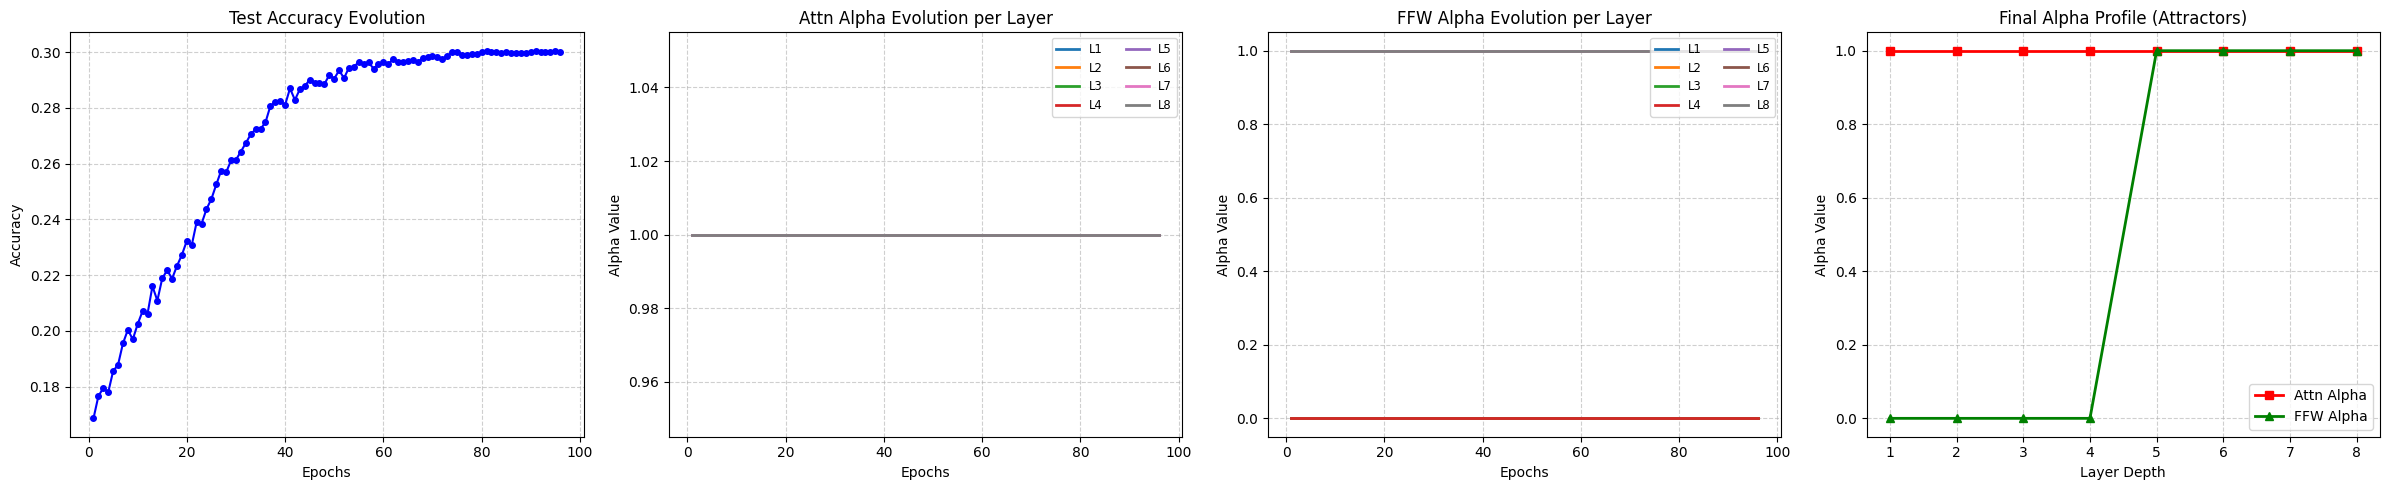

Final Test Accuracy: 0.3002

Final Alpha values per layer:
Layer    | Attn Alpha   | FFW Alpha   
--------------------------------------
 Layer 1  | 1.0000       | 0.0000      
 Layer 2  | 1.0000       | 0.0000      
 Layer 3  | 1.0000       | 0.0000      
 Layer 4  | 1.0000       | 0.0000      
 Layer 5  | 1.0000       | 1.0000      
 Layer 6  | 1.0000       | 1.0000      
 Layer 7  | 1.0000       | 1.0000      
 Layer 8  | 1.0000       | 1.0000      


In [135]:
# Plotting results
# Convert lists to numpy array

acc_array = np.array(accuracy_history)
attn_alpha_array = np.array(attn_alpha_history)
ffw_alpha_array = np.array(ffw_alpha_history)

#PLOTS
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Accuracy
axes[0].plot(range(1, len(acc_array) + 1), acc_array, marker='o', color='b', markersize=4)
axes[0].set_title('Test Accuracy Evolution')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Attention Alpha Evolution
for layer_idx in range(attn_alpha_array.shape[1]):
    axes[1].plot(range(1, len(attn_alpha_array) + 1), attn_alpha_array[:, layer_idx],
                 label=f'L{layer_idx + 1}', linewidth=2)

axes[1].set_title('Attn Alpha Evolution per Layer')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Alpha Value')
axes[1].legend(loc='upper right', fontsize='small', ncol=2)
axes[1].grid(True, linestyle='--', alpha=0.6)

#  FFW Alpha Evolution
for layer_idx in range(ffw_alpha_array.shape[1]):
    axes[2].plot(range(1, len(ffw_alpha_array) + 1), ffw_alpha_array[:, layer_idx],
                 label=f'L{layer_idx + 1}', linewidth=2)

axes[2].set_title('FFW Alpha Evolution per Layer')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Alpha Value')
axes[2].legend(loc='upper right', fontsize='small', ncol=2)
axes[2].grid(True, linestyle='--', alpha=0.6)

# Final Alpha Profiles (Comparison)
final_attn_alphas = attn_alpha_array[-1, :]
final_ffw_alphas = ffw_alpha_array[-1, :]
layers = range(1, len(final_attn_alphas) + 1)

axes[3].plot(layers, final_attn_alphas, marker='s', color='r', linewidth=2, label='Attn Alpha')
axes[3].plot(layers, final_ffw_alphas, marker='^', color='g', linewidth=2, label='FFW Alpha')
axes[3].set_title('Final Alpha Profile (Attractors)')
axes[3].set_xlabel('Layer Depth')
axes[3].set_ylabel('Alpha Value')
axes[3].set_xticks(layers)
axes[3].legend(loc='best')
axes[3].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"Final Test Accuracy: {acc_array[-1]:.4f}")
print("\nFinal Alpha values per layer:")
print(f"{'Layer':<8} | {'Attn Alpha':<12} | {'FFW Alpha':<12}")
print("-" * 38)
for i, (a_val, f_val) in enumerate(zip(final_attn_alphas, final_ffw_alphas)):
    print(f" Layer {i+1:<2} | {a_val:<12.4f} | {f_val:<12.4f}")

# Probing

In [138]:
class HierarchicalProber(nn.Module):
    def __init__(self, d_model=128, num_classes=2):
        super().__init__()
        # Simple MLP to probe the frozen representations
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x):
        return self.mlp(x)

In [139]:
# Freeze the base model completely
for param in model.parameters():
    param.requires_grad = False

# Set base model to eval mode permanently for the probing phase
model.eval()

# Initialize the Prober
prober = HierarchicalProber(d_model=128, num_classes=2).to(device)
prober_criterion = nn.CrossEntropyLoss()
prober_optimizer = optim.Adam(prober.parameters(), lr=1e-3)
prober_epochs = 30 # Probers usually converge very fast


prober_loss_history = []
prober_acc_history = []

for epoch in range(prober_epochs):
    prober.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # Extract hidden states from the frozen base model
        with torch.no_grad():
            # return_hiddens=True returns (logits, final_output)
            _, final_output = model(batch_x, return_hiddens=True)
            

            # we extract token 7 from layer 8
            # Shape goes from (batch_size, seq_len, d_model) -> (batch_size, d_model)
            final_token_hiddens = final_output[:, -2, :] 

        # Train the prober on these frozen representations
        prober_optimizer.zero_grad()

        # Prober tries to predict the root class (0 or 1)
        probe_logits = prober(final_token_hiddens)
        loss = prober_criterion(probe_logits, batch_y)

        loss.backward()
        prober_optimizer.step()

        total_loss += loss.item()

        # Calculate training accuracy
        predictions = torch.argmax(probe_logits, dim=1)
        correct += (predictions == batch_y).sum().item()
        total += batch_y.size(0)

    # Evaluation on test set
    prober.eval()
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for test_x, test_y in test_loader:
            test_x, test_y = test_x.to(device), test_y.to(device)

            _, test_output = model(test_x, return_hiddens=True)
            test_final_hiddens = test_output[:, -2, :]

            test_logits = prober(test_final_hiddens)
            test_preds = torch.argmax(test_logits, dim=1)

            test_correct += (test_preds == test_y).sum().item()
            test_total += test_y.size(0)

    train_acc = correct / total
    test_acc = test_correct / test_total

    print(f"Probe Epoch {epoch+1}/{prober_epochs} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Probe Epoch 1/30 | Loss: 0.6750 | Train Acc: 0.5756 | Test Acc: 0.5989
Probe Epoch 2/30 | Loss: 0.6520 | Train Acc: 0.6139 | Test Acc: 0.6163
Probe Epoch 3/30 | Loss: 0.6376 | Train Acc: 0.6263 | Test Acc: 0.6232
Probe Epoch 4/30 | Loss: 0.6247 | Train Acc: 0.6421 | Test Acc: 0.6217
Probe Epoch 5/30 | Loss: 0.6134 | Train Acc: 0.6466 | Test Acc: 0.6331
Probe Epoch 6/30 | Loss: 0.6044 | Train Acc: 0.6639 | Test Acc: 0.6436
Probe Epoch 7/30 | Loss: 0.5913 | Train Acc: 0.6762 | Test Acc: 0.6446
Probe Epoch 8/30 | Loss: 0.5821 | Train Acc: 0.6837 | Test Acc: 0.6543
Probe Epoch 9/30 | Loss: 0.5711 | Train Acc: 0.6937 | Test Acc: 0.6573
Probe Epoch 10/30 | Loss: 0.5638 | Train Acc: 0.6968 | Test Acc: 0.6631
Probe Epoch 11/30 | Loss: 0.5554 | Train Acc: 0.7016 | Test Acc: 0.6630
Probe Epoch 12/30 | Loss: 0.5453 | Train Acc: 0.7121 | Test Acc: 0.6582
Probe Epoch 13/30 | Loss: 0.5396 | Train Acc: 0.7141 | Test Acc: 0.6631
Probe Epoch 14/30 | Loss: 0.5329 | Train Acc: 0.7199 | Test Acc: 0.6709
P